In [10]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import load_iris
import pandas as pd


In [11]:
iris = load_iris()
print(iris)
#5 arrtibutes: sepal length, sepal width, petal length, petal width, species

{'data': array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
     

In [12]:
colums = ['sepal length', 'sepal width', 'petal length', 'petal width', 'species']
df = pd.read_csv('data/iris.data', names=colums, header=None)
print(df.shape)
df.head()
df.tail()

(150, 5)


,sepal length,sepal width,petal length,petal width,species
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica
149,5.9,3.0,5.1,1.8,Iris-virginica


In [13]:
df.info()
df['species'].value_counts()
#use the first 4 measurements as features and the last column as the target variable
x = df.drop('species', axis=1)
y = df['species']

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal length  150 non-null    float64
 1   sepal width   150 non-null    float64
 2   petal length  150 non-null    float64
 3   petal width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [14]:
#Train /test split 
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, stratify=y, random_state=42)
print(x_train.shape, x_test.shape, y_train.shape, y_test.shape)

(120, 4) (30, 4) (120,) (30,)


In [15]:
#Build a pipeline 
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression())
])


In [16]:
import time
#training time for question 6a & 6b

start = time.perf_counter()
pipe.fit(x_train, y_train)
train_time = time.perf_counter() - start
y_pred = pipe.predict(x_test)
test_time = time.perf_counter() - start

print(f"Training time: {train_time:.4f} seconds")
print(f"Test time: {test_time:.4f} seconds")


Training time: 0.0318 seconds
Test time: 0.0328 seconds


Test accuracy: 0.9333


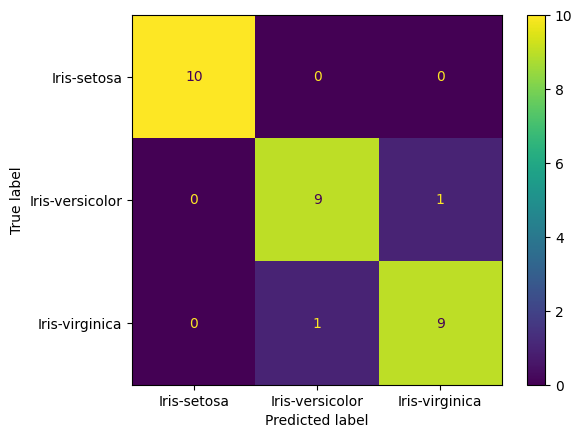

In [17]:
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay

print(f"Test accuracy: {accuracy_score(y_test, y_pred):.4f}")
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

The confusion matrix, rows are the true species and columns are what the model predicted

In [18]:
#optionals:
for C in [0.01, 0.1, 1, 10, 100]:
    pipe.set_params(classifier__C=C)
    pipe.fit(x_train, y_train)
    acc = accuracy_score(y_test, pipe.predict(x_test))
    print(f"C = {C:>6}: accuracy = {acc:.4f}")

C =   0.01: accuracy = 0.8000
C =    0.1: accuracy = 0.8667
C =      1: accuracy = 0.9333
C =     10: accuracy = 1.0000
C =    100: accuracy = 1.0000
